# Evaluation and Empirical Results
## CI (Code-execution Invocation) vs DI (Direct Invocation) across Task Types

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
import statsmodels.formula.api as smf
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.linewidth': 0.8,
    'axes.grid': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'legend.frameon': False,
})

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

SHADE_DI = '#b3b3b3'
SHADE_CI = '#4d4d4d'
HATCH_DI = ''
HATCH_CI = '///'

In [ ]:
df = pd.read_csv('final_merged_updated.csv')

TASK_MAP = {'T1': 'Single-tool', 'T2': 'Pipeline', 'T3': 'Discovery'}
AGENT_MAP = {
    'A1': 'Single-agent DI', 'A2': 'Single-agent CI',
    'A3': 'Multi-agent DI', 'A4': 'Multi-agent CI'
}
TASK_ORDER = ['T1', 'T2', 'T3']
TASK_LABELS = ['Single-tool', 'Pipeline', 'Discovery']

df['task_label'] = df['task_type'].map(TASK_MAP)
df['agent_name'] = df['agent_label'].map(AGENT_MAP)
df['mode'] = df['agent_label'].apply(lambda x: 'CI' if x in ['A2', 'A4'] else 'DI')
df['is_code'] = (df['mode'] == 'CI').astype(int)
df['is_multi'] = df['agent_label'].apply(lambda x: 1 if x in ['A3', 'A4'] else 0)

df['efficiency'] = df['task_grade'] / (df['total_tokens'] / 1000).replace(0, np.nan)

a1_eff = df[df['agent_label'] == 'A1'].groupby('task_type')['efficiency'].mean()
df['efficiency_norm'] = df.apply(
    lambda r: r['efficiency'] / a1_eff[r['task_type']], axis=1
)

print(f'Loaded {len(df)} runs | Modes: {df["mode"].value_counts().to_dict()}')
print(f'Task types: {df["task_type"].value_counts().sort_index().to_dict()}')

Loaded 582 runs | Modes: {'DI': 294, 'CI': 288}
Task types: {'T1': 204, 'T2': 216, 'T3': 162}


In [25]:
def ci_95(series):
    n = len(series.dropna())
    if n < 2:
        return 0
    return stats.t.ppf(0.975, n - 1) * series.std() / np.sqrt(n)

def run_ttest(g1, g2):
    t_stat, p_val = stats.ttest_ind(g1.dropna(), g2.dropna(), equal_var=False)
    cohen_d = (g1.mean() - g2.mean()) / np.sqrt((g1.std()**2 + g2.std()**2) / 2)
    return t_stat, p_val, cohen_d

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return ''

SERVER_ORDER = ['cocktails', 'cross_server', 'devtoolkit', 'lastfm',
                'morse', 'nasa', 'nutrition', 'postgres']
SERVER_LABELS = ['Cocktails', 'Cross-server', 'DevToolkit', 'LastFM',
                 'Morse', 'NASA', 'Nutrition', 'Postgres']

def plot_mode_by_task(metric, ylabel, title, filename, ylim=None, agents=None):
    src = df if agents is None else df[df['agent_label'].isin(agents)]
    fig, ax = plt.subplots(figsize=(7, 4))
    x = np.arange(len(TASK_ORDER))
    width = 0.35

    for i, (mode, shade, hatch, label) in enumerate([
        ('DI', SHADE_DI, HATCH_DI, 'Direct Invocation (DI)'),
        ('CI', SHADE_CI, HATCH_CI, 'Code-execution Invocation (CI)')
    ]):
        means, cis = [], []
        for tt in TASK_ORDER:
            subset = src[(src['task_type'] == tt) & (src['mode'] == mode)][metric]
            means.append(subset.mean())
            cis.append(ci_95(subset))
        ax.bar(x + i * width, means, width, yerr=cis, color=shade, hatch=hatch,
               edgecolor='black', linewidth=0.5, capsize=3, label=label,
               error_kw={'linewidth': 0.8})

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(TASK_LABELS)
    ax.set_ylabel(ylabel)
    ax.legend(loc='best')
    if ylim:
        ax.set_ylim(ylim)
    fig.savefig(FIGURES_DIR / f'{filename}.pdf')
    fig.savefig(FIGURES_DIR / f'{filename}.png')
    plt.show()
    return fig

def plot_ci_by_x(x_col, x_order, x_labels, metric, ylabel, filename,
                 ylim=None, figsize=(7, 4), rot=0):
    ci_df = df[df['agent_label'].isin(['A2', 'A4'])]
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(x_order))
    width = 0.35

    for i, (agent, shade, hatch, label) in enumerate([
        ('A2', SHADE_DI, HATCH_DI, 'Single Agent CI'),
        ('A4', SHADE_CI, HATCH_CI, 'Multi Agent CI')
    ]):
        means, cis = [], []
        for xv in x_order:
            subset = ci_df[(ci_df[x_col] == xv) & (ci_df['agent_label'] == agent)][metric]
            means.append(subset.mean())
            cis.append(ci_95(subset))
        ax.bar(x + i * width, means, width, yerr=cis, color=shade, hatch=hatch,
               edgecolor='black', linewidth=0.5, capsize=3, label=label,
               error_kw={'linewidth': 0.8})

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(x_labels, rotation=rot, ha='right' if rot else 'center')
    ax.set_ylabel(ylabel)
    ax.legend(loc='best')
    if ylim:
        ax.set_ylim(ylim)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f'{filename}.pdf')
    fig.savefig(FIGURES_DIR / f'{filename}.png')
    plt.show()
    return fig

## 1. Task Grade by Invocation Mode

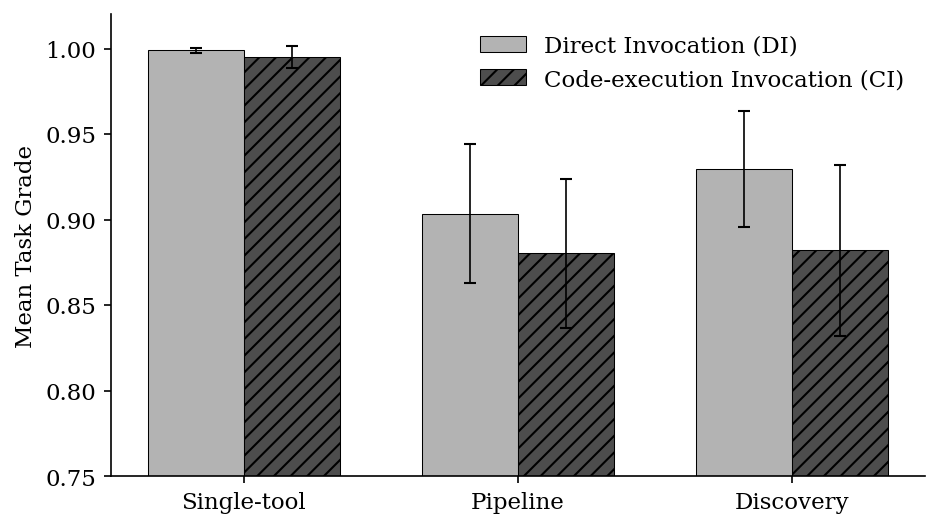


--- T-tests: Grade (CI vs DI) per task type ---
  Single-tool: DI=0.9990 CI=0.9951 | t=1.214, p=0.2272, d=0.170
  Pipeline: DI=0.9035 CI=0.8804 | t=0.770, p=0.4420, d=0.105
  Discovery: DI=0.9298 CI=0.8821 | t=1.576, p=0.1173, d=0.249

One-way ANOVA (grade ~ mode): F=2.456, p=0.1176


In [26]:
plot_mode_by_task('task_grade', 'Mean Task Grade', 'Task Grade by Invocation Mode',
                  'eval_grade_by_mode_task', ylim=(0.75, 1.02))

print('\n--- T-tests: Grade (CI vs DI) per task type ---')
for tt, tl in zip(TASK_ORDER, TASK_LABELS):
    ci = df[(df['task_type'] == tt) & (df['mode'] == 'CI')]['task_grade']
    di = df[(df['task_type'] == tt) & (df['mode'] == 'DI')]['task_grade']
    t, p, d = run_ttest(di, ci)
    print(f'  {tl}: DI={di.mean():.4f} CI={ci.mean():.4f} | '
          f't={t:.3f}, p={p:.4f}{sig_stars(p)}, d={d:.3f}')

groups = [g['task_grade'].values for _, g in df.groupby('mode')]
f_stat, p_val = stats.f_oneway(*groups)
print(f'\nOne-way ANOVA (grade ~ mode): F={f_stat:.3f}, p={p_val:.4f}{sig_stars(p_val)}')

## 2. Normalized Efficiency by Invocation Mode

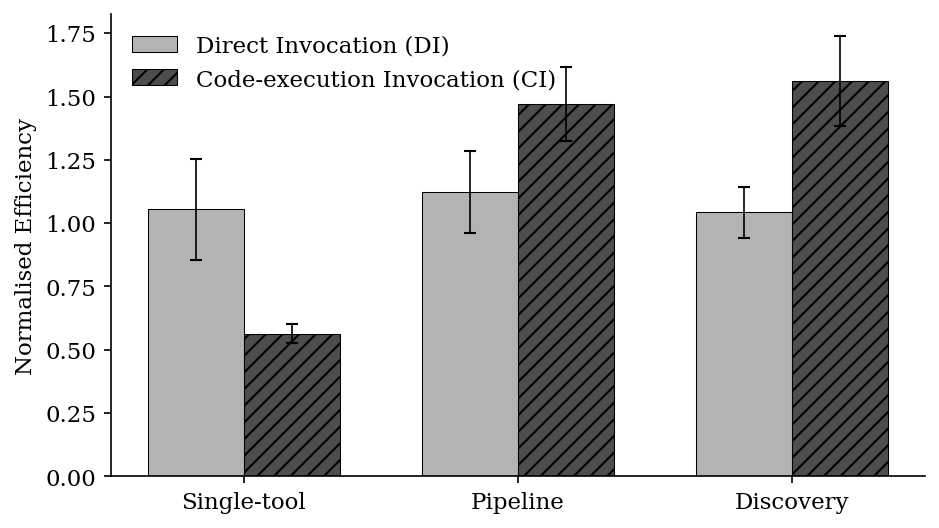


--- T-tests: Normalized Efficiency (CI vs DI) per task type ---
  Single-tool: DI=1.0545 CI=0.5638 | t=-4.823, p=0.0000***, d=-0.675
  Pipeline: DI=1.1232 CI=1.4717 | t=3.162, p=0.0018**, d=0.430
  Discovery: DI=1.0422 CI=1.5598 | t=5.059, p=0.0000***, d=0.803

One-way ANOVA (efficiency_norm ~ mode): F=2.171, p=0.1412


In [27]:
plot_mode_by_task('efficiency_norm', 'Normalised Efficiency',
                  'Normalised Efficiency by Invocation Mode',
                  'eval_efficiency_by_mode_task')

print('\n--- T-tests: Normalized Efficiency (CI vs DI) per task type ---')
for tt, tl in zip(TASK_ORDER, TASK_LABELS):
    ci = df[(df['task_type'] == tt) & (df['mode'] == 'CI')]['efficiency_norm']
    di = df[(df['task_type'] == tt) & (df['mode'] == 'DI')]['efficiency_norm']
    t, p, d = run_ttest(ci, di)
    print(f'  {tl}: DI={di.mean():.4f} CI={ci.mean():.4f} | '
          f't={t:.3f}, p={p:.4f}{sig_stars(p)}, d={d:.3f}')

groups = [g['efficiency_norm'].dropna().values for _, g in df.groupby('mode')]
f_stat, p_val = stats.f_oneway(*groups)
print(f'\nOne-way ANOVA (efficiency_norm ~ mode): F={f_stat:.3f}, p={p_val:.4f}{sig_stars(p_val)}')

## 3. Token Consumption by Invocation Mode

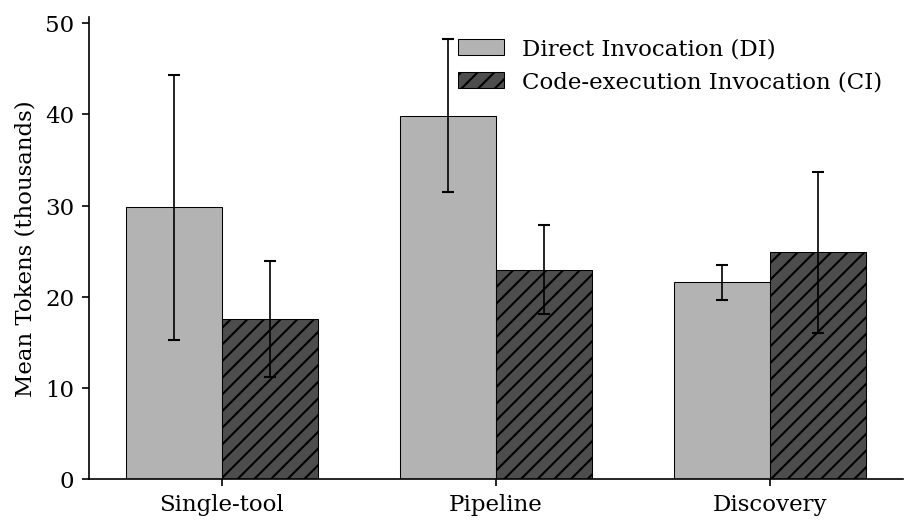


--- T-tests: Tokens (CI vs DI) per task type ---
  Single-tool: DI=29,825 CI=17,541 | t=1.538, p=0.1263, d=0.215
  Pipeline: DI=39,873 CI=22,999 | t=3.453, p=0.0007***, d=0.470
  Discovery: DI=21,584 CI=24,883 | t=-0.728, p=0.4684, d=-0.116

One-way ANOVA (tokens ~ mode): F=7.205, p=0.0075**


In [28]:
df['tokens_k'] = df['total_tokens'] / 1000
plot_mode_by_task('tokens_k', 'Mean Tokens (thousands)',
                  'Token Consumption by Invocation Mode',
                  'eval_tokens_by_mode_task')

print('\n--- T-tests: Tokens (CI vs DI) per task type ---')
for tt, tl in zip(TASK_ORDER, TASK_LABELS):
    ci = df[(df['task_type'] == tt) & (df['mode'] == 'CI')]['total_tokens']
    di = df[(df['task_type'] == tt) & (df['mode'] == 'DI')]['total_tokens']
    t, p, d = run_ttest(di, ci)
    print(f'  {tl}: DI={di.mean():,.0f} CI={ci.mean():,.0f} | '
          f't={t:.3f}, p={p:.4f}{sig_stars(p)}, d={d:.3f}')

groups = [g['total_tokens'].values for _, g in df.groupby('mode')]
f_stat, p_val = stats.f_oneway(*groups)
print(f'\nOne-way ANOVA (tokens ~ mode): F={f_stat:.3f}, p={p_val:.4f}{sig_stars(p_val)}')

## 4. Code Invocation (Single Agent vs Multi Agent): Efficienty by Task Type

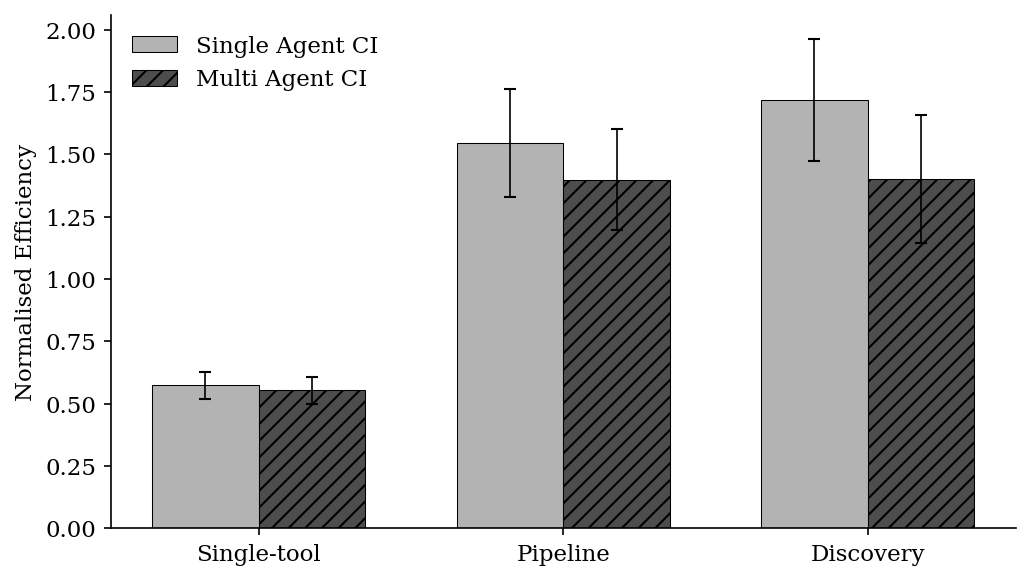


--- T-tests: Normalised Efficiency (Single CI A2 vs Multi CI A4) per task type ---
  Single-tool: Single=0.5733 Multi=0.5543 | t=0.504, p=0.6156, d=0.100
  Pipeline: Single=1.5455 Multi=1.3980 | t=1.004, p=0.3179, d=0.193
  Discovery: Single=1.7175 Multi=1.4022 | t=1.794, p=0.0768, d=0.406

One-way ANOVA (efficiency_norm ~ agent_label, CI only): F=2.612, p=0.1072


In [29]:
plot_ci_by_x('task_type', TASK_ORDER, TASK_LABELS,
             'efficiency_norm', 'Normalised Efficiency',
             'eval_ci_efficiency_by_agent_type_task')

print('\n--- T-tests: Normalised Efficiency (Single CI A2 vs Multi CI A4) per task type ---')
ci_df = df[df['agent_label'].isin(['A2', 'A4'])]
for tt, tl in zip(TASK_ORDER, TASK_LABELS):
    sa = ci_df[(ci_df['task_type'] == tt) & (ci_df['agent_label'] == 'A2')]['efficiency_norm']
    ma = ci_df[(ci_df['task_type'] == tt) & (ci_df['agent_label'] == 'A4')]['efficiency_norm']
    t, p, d = run_ttest(sa, ma)
    print(f'  {tl}: Single={sa.mean():.4f} Multi={ma.mean():.4f} | '
          f't={t:.3f}, p={p:.4f}{sig_stars(p)}, d={d:.3f}')

groups = [g['efficiency_norm'].dropna().values
          for _, g in ci_df.groupby('agent_label')]
f_stat, p_val = stats.f_oneway(*groups)
print(f'\nOne-way ANOVA (efficiency_norm ~ agent_label, CI only): '
      f'F={f_stat:.3f}, p={p_val:.4f}{sig_stars(p_val)}')

## 5. Code Invocation (Single Agent vs Multi Agent): Efficienty by Server

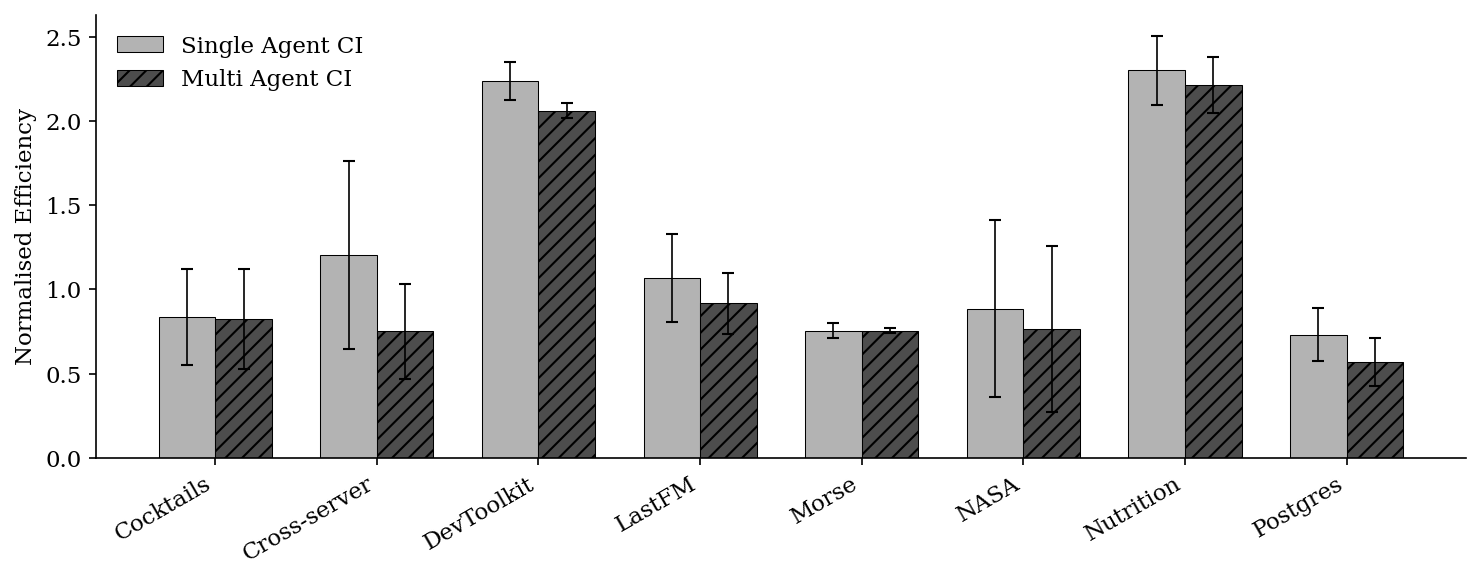


--- T-tests: Normalised Efficiency (Single CI A2 vs Multi CI A4) per server ---
  Cocktails: Single=0.8374 Multi=0.8219 | t=0.081, p=0.9364, d=0.029
  Cross-server: Single=1.2047 Multi=0.7513 | t=1.677, p=0.1197, d=0.790
  DevToolkit: Single=2.2387 Multi=2.0608 | t=3.079, p=0.0048**, d=0.931
  LastFM: Single=1.0688 Multi=0.9167 | t=0.987, p=0.3288, d=0.269
  Morse: Single=0.7550 Multi=0.7556 | t=-0.027, p=0.9790, d=-0.010
  NASA: Single=0.8865 Multi=0.7655 | t=0.361, p=0.7210, d=0.132
  Nutrition: Single=2.3013 Multi=2.2112 | t=0.732, p=0.4704, d=0.267
  Postgres: Single=0.7318 Multi=0.5681 | t=1.604, p=0.1149, d=0.441


In [30]:
plot_ci_by_x('server', SERVER_ORDER, SERVER_LABELS,
             'efficiency_norm', 'Normalised Efficiency',
             'eval_ci_efficiency_by_agent_type_server',
             figsize=(10, 4), rot=30)

print('\n--- T-tests: Normalised Efficiency (Single CI A2 vs Multi CI A4) per server ---')
ci_df = df[df['agent_label'].isin(['A2', 'A4'])]
for sv, sl in zip(SERVER_ORDER, SERVER_LABELS):
    sa = ci_df[(ci_df['server'] == sv) & (ci_df['agent_label'] == 'A2')]['efficiency_norm']
    ma = ci_df[(ci_df['server'] == sv) & (ci_df['agent_label'] == 'A4')]['efficiency_norm']
    t, p, d = run_ttest(sa, ma)
    print(f'  {sl}: Single={sa.mean():.4f} Multi={ma.mean():.4f} | '
          f't={t:.3f}, p={p:.4f}{sig_stars(p)}, d={d:.3f}')

## 6. Token Consumption by Invocation Mode (Single Agent)

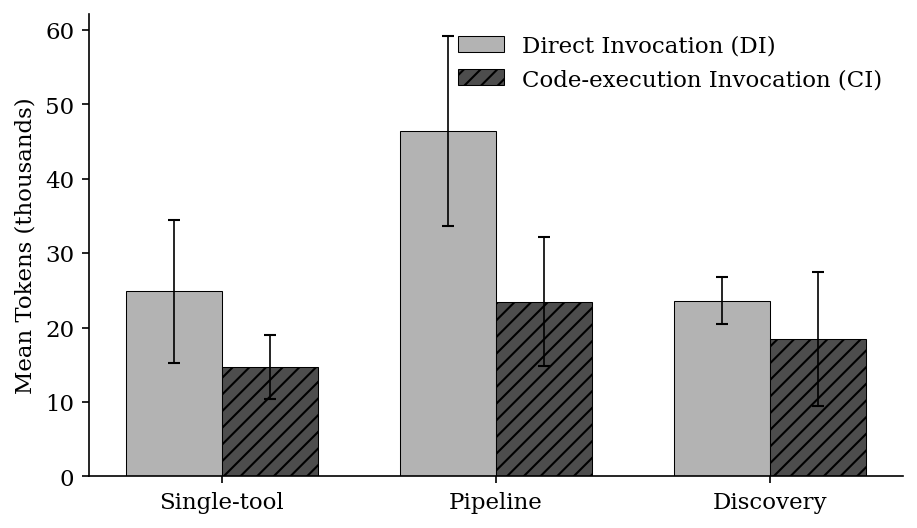


--- T-tests: Tokens (CI vs DI) per task type — single agent only ---
  Single-tool: DI=24,869 CI=14,672 | t=1.954, p=0.0547, d=0.387
  Pipeline: DI=46,390 CI=23,465 | t=2.980, p=0.0037**, d=0.573
  Discovery: DI=23,587 CI=18,518 | t=1.077, p=0.2871, d=0.243

One-way ANOVA (tokens ~ mode, single agent): F=12.964, p=0.0004***


In [31]:
plot_mode_by_task('tokens_k', 'Mean Tokens (thousands)',
                  'Token Consumption by Invocation Mode (Single Agent)',
                  'eval_tokens_by_mode_task_single', agents=['A1', 'A2'])

print('\n--- T-tests: Tokens (CI vs DI) per task type — single agent only ---')
sa_df = df[df['agent_label'].isin(['A1', 'A2'])]
for tt, tl in zip(TASK_ORDER, TASK_LABELS):
    ci = sa_df[(sa_df['task_type'] == tt) & (sa_df['mode'] == 'CI')]['total_tokens']
    di = sa_df[(sa_df['task_type'] == tt) & (sa_df['mode'] == 'DI')]['total_tokens']
    t, p, d = run_ttest(di, ci)
    print(f'  {tl}: DI={di.mean():,.0f} CI={ci.mean():,.0f} | '
          f't={t:.3f}, p={p:.4f}{sig_stars(p)}, d={d:.3f}')

groups = [g['total_tokens'].values for _, g in sa_df.groupby('mode')]
f_stat, p_val = stats.f_oneway(*groups)
print(f'\nOne-way ANOVA (tokens ~ mode, single agent): '
      f'F={f_stat:.3f}, p={p_val:.4f}{sig_stars(p_val)}')

## 7. Normalised Efficiency by Invocation Mode (Single Agent)

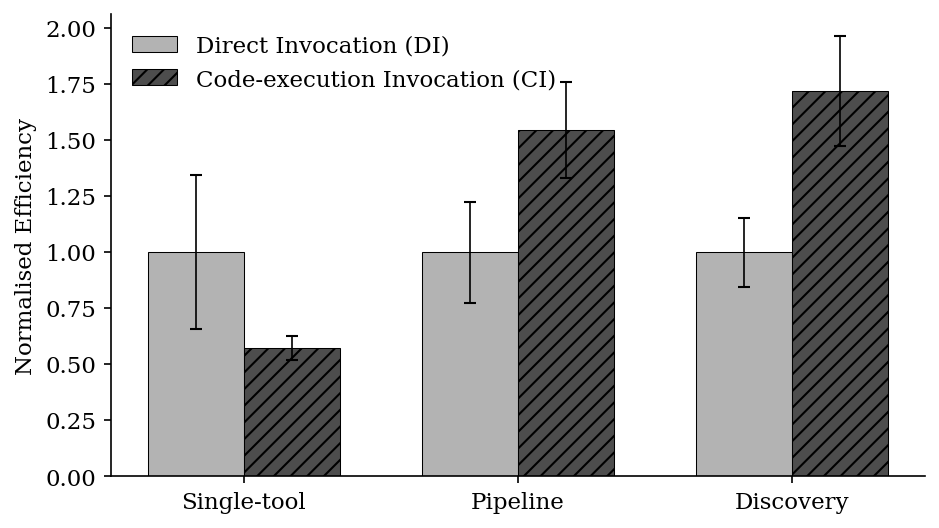


--- T-tests: Normalised Efficiency (CI vs DI) per task type — single agent only ---
  Single-tool: DI=1.0000 CI=0.5733 | t=-2.459, p=0.0173*, d=-0.487
  Pipeline: DI=1.0000 CI=1.5455 | t=3.520, p=0.0006***, d=0.677
  Discovery: DI=1.0000 CI=1.7175 | t=5.003, p=0.0000***, d=1.121

One-way ANOVA (efficiency_norm ~ mode, single agent): F=6.030, p=0.0146*


In [32]:
plot_mode_by_task('efficiency_norm', 'Normalised Efficiency',
                  'Normalised Efficiency by Invocation Mode (Single Agent)',
                  'eval_efficiency_by_mode_task_single', agents=['A1', 'A2'])

print('\n--- T-tests: Normalised Efficiency (CI vs DI) per task type — single agent only ---')
sa_df = df[df['agent_label'].isin(['A1', 'A2'])]
for tt, tl in zip(TASK_ORDER, TASK_LABELS):
    ci = sa_df[(sa_df['task_type'] == tt) & (sa_df['mode'] == 'CI')]['efficiency_norm']
    di = sa_df[(sa_df['task_type'] == tt) & (sa_df['mode'] == 'DI')]['efficiency_norm']
    t, p, d = run_ttest(ci, di)
    print(f'  {tl}: DI={di.mean():.4f} CI={ci.mean():.4f} | '
          f't={t:.3f}, p={p:.4f}{sig_stars(p)}, d={d:.3f}')

groups = [g['efficiency_norm'].dropna().values for _, g in sa_df.groupby('mode')]
f_stat, p_val = stats.f_oneway(*groups)
print(f'\nOne-way ANOVA (efficiency_norm ~ mode, single agent): '
      f'F={f_stat:.3f}, p={p_val:.4f}{sig_stars(p_val)}')